# Importing

In [1]:
# %% Cell 1: Imports
from doctest import OutputChecker

import pandas as pd
import numpy as np
from darts import TimeSeries
from darts.metrics import mae
from darts.models import ARIMA, LinearRegressionModel, RandomForest, XGBModel

seed = 24775456

import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
import pyarrow as pa
import datetime as dt


# %% Cell 2: Load Data
def loadData():
    df = pd.read_parquet("gafanha.parquet")
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.round("h")
    print(df.count())
    return (
        df.pivot_table(index="timestamp", columns="collection", values="value", aggfunc="median")
        .asfreq("h")
        .loc[:"2024-12-31 23:00"]
        .reset_index()
    )

df = loadData()




# %% Cell 3: Readings per day per variable - for validating the dataset only
def checkDailyCount(df):
    df_daily_counts = df.set_index("timestamp").resample("D").count()

    # quick visual: counts per year for each variable
    df_daily_counts.groupby(df_daily_counts.index.year).mean().plot(
        kind="bar", figsize=(12, 5), title="Avg daily reading count per variable, by year"
    )
    plt.ylabel("avg readings/day")
    plt.tight_layout()
    plt.show()

station       916774
timestamp     916774
collection    916774
value         916774
unit          916774
source_db     916774
date          916774
values        916774
dtype: int64


# Load Data 

In [2]:
# %% Cell 4: Force daily, median and fill in missing values with darts package
from darts.utils.missing_values import fill_missing_values
daily = df.set_index("timestamp").resample("D").median()
daily = daily.asfreq("D")

print(daily.count())


# Set up the AQI bins for each pollutant based on the standard AQI breakpoints (European standards)
aqi_bins = {
    "PM25": [-np.inf, 10, 20, 25, 50, np.inf],
    "PM10": [-np.inf, 20, 35, 50, 100, np.inf],
    "NO2":  [-np.inf, 40, 100, 200, 400, np.inf],
    "O3":   [-np.inf, 80, 120, 180, 240, np.inf],
    "SO2":  [-np.inf, 100, 200, 350, 500, np.inf],
}
sub_idx = pd.concat(
    [pd.cut(daily[p], bins=b, labels=[1, 2, 3, 4, 5]).astype(float) for p, b in aqi_bins.items()],
    axis=1,
)
daily["AQI"] = sub_idx.max(axis=1, skipna=True)
dominant = sub_idx.dropna(how="all").idxmax(axis=1)
last_valid = daily["AQI"].last_valid_index() 
print(last_valid)

# interpolates NaNs values
daily.index = daily.index.tz_localize(None)
series = TimeSeries.from_dataframe(daily, freq="D")
series = fill_missing_values(series)

collection
Benzene          2963
CO               3010
NO               2979
NO2              2979
NOx              2979
O3               3008
PM10             2632
PM25             2626
Particles        2626
Precipitation     366
Radiation         366
SO2              2990
Temperature      2635
WindDirection    3001
WindSpeed        3001
dtype: int64
2024-12-31 00:00:00+00:00


In [3]:
print(sub_idx.notna().groupby(sub_idx.index.year).mean())
dominant.groupby(dominant.index.year).value_counts(normalize=True).unstack()

               PM25      PM10       NO2        O3       SO2
timestamp                                                  
2016       1.000000  1.000000  1.000000  1.000000  1.000000
2017       1.000000  1.000000  0.997260  1.000000  1.000000
2018       0.835616  0.835616  0.819178  0.835616  0.832877
2019       1.000000  1.000000  0.994521  0.989041  0.975342
2020       0.972678  0.991803  0.948087  0.991803  0.991803
2021       0.980822  0.978082  1.000000  1.000000  1.000000
2022       1.000000  1.000000  0.994521  1.000000  0.986301
2023       0.983562  0.983562  0.983562  1.000000  0.986301
2024       0.000000  0.000000  1.000000  1.000000  0.994536


,NO2,O3,PM10,PM25
timestamp,,,,
2016,NaN,0.013072,0.346405,0.640523
2017,NaN,0.027397,0.405479,0.567123
2018,NaN,0.026230,0.767213,0.206557
2019,NaN,0.021918,0.536986,0.441096
2020,NaN,0.071429,0.109890,0.818681
2021,0.019178,0.082192,0.082192,0.816438
2022,NaN,0.032877,0.060274,0.906849
2023,0.005479,0.095890,0.041096,0.857534
2024,0.770492,0.229508,NaN,NaN


1844 615 616


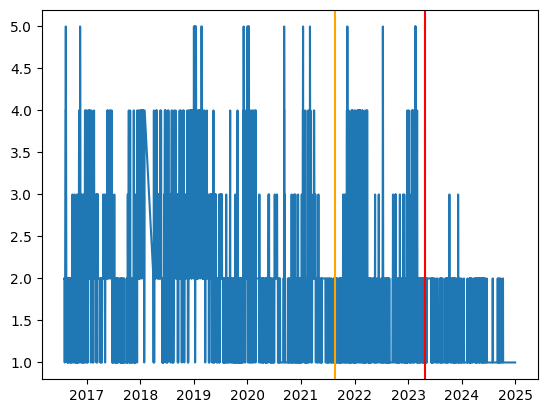

In [14]:
# %% Cell 5: set target and split
target = series["AQI"]
covariates = series.drop_columns(["AQI"])
y_train, y_temp = target.split_before(0.6)
y_val, y_test = y_temp.split_before(0.5)

x_train, x_temp = covariates.split_before(0.6)
x_val, x_test = x_temp.split_before(0.5)



print(len(y_train), len(y_val), len(y_test))
plt.plot(target.time_index, target.values())
plt.axvline(y_val.start_time(), color="orange")
plt.axvline(y_test.start_time(), color="red")
plt.show()

# Parameter finding

In [15]:
# %% Cell 6: Hyperparameter search for XGBoost
import optuna
from darts.models import XGBModel
from darts.metrics import rmse, mape, mae

fixed_param = dict(output_chunk_length=1, tree_method="hist", n_jobs=-1,
             random_state=seed, objective="reg:absoluteerror")


def findParam(trial):
    model = XGBModel(
        lags=trial.suggest_int("lags", 7, 60),
        lags_past_covariates=trial.suggest_int("lags_past_covariates", 7, 30),
        n_estimators=trial.suggest_int("n_estimators", 50, 400),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        **fixed_param,
    )
    model.fit(y_train, past_covariates=x_train, verbose=False)

    preds = model.historical_forecasts(
        series=y_train.append(y_val),
        past_covariates=x_train.append(x_val),
        start=y_val.start_time(),
        forecast_horizon=1,
        stride=1,
        retrain=False,
        last_points_only=True,
        verbose=False,
    ).map(lambda x: np.round(x))

    return rmse(y_val, preds), mae(y_val, preds), mape(y_val, preds)

study = optuna.create_study(directions=["minimize", "minimize", "minimize"], sampler=optuna.samplers.TPESampler(seed=seed))
study.optimize(findParam, n_trials=500, show_progress_bar=True, n_jobs=1)
print(f"{len(study.best_trials)} trials on the Pareto front")

[I 2026-09-28 17:13:19,889] A new study created in memory with name: no-name-8d70996e-6ef3-4869-ad4c-122496d3757c


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-09-28 17:13:20,117] Trial 0 finished with values: [0.8429526117707073, 0.5544715447154471, 35.37398373983739] and parameters: {'lags': 46, 'lags_past_covariates': 13, 'n_estimators': 107, 'max_depth': 3, 'learning_rate': 0.1051338177357635, 'subsample': 0.9815791144603465, 'colsample_bytree': 0.5237576608043644}.
[I 2026-09-28 17:13:21,780] Trial 1 finished with values: [0.8563488385776752, 0.5804878048780487, 39.135501355013545] and parameters: {'lags': 12, 'lags_past_covariates': 19, 'n_estimators': 128, 'max_depth': 8, 'learning_rate': 0.2450731483153269, 'subsample': 0.707680880334272, 'colsample_bytree': 0.5825108547624366}.
[I 2026-09-28 17:13:25,027] Trial 2 finished with values: [0.8788388496062494, 0.6032520325203252, 40.68021680216802] and parameters: {'lags': 31, 'lags_past_covariates': 12, 'n_estimators': 335, 'max_depth': 9, 'learning_rate': 0.24316041076712683, 'subsample': 0.7673108633345813, 'colsample_bytree': 0.7591357239711332}.
[I 2026-09-28 17:13:27,953] Tr

In [16]:
# %% Cell 7 checking final model, retrain on train-val and oneshot-shot eval on test
final_y_train = y_train.append(y_val)
final_x_train = x_train.append(x_val)

# Find the best trial based on the sum of normalized objectives (RMSE, MAE, MAPE)
vals = np.array([t.values for t in study.best_trials])
best_trial = study.best_trials[np.argmin((vals / vals.min(axis=0)).sum(axis=1))]


best_params = best_trial.params
print(f"chosen params: {best_params}")
print(f"val rmse/mae/mape: {best_trial.values} for trial {best_trial.number}")

best_model = XGBModel(**best_params, **fixed_param)

test_pred = best_model.historical_forecasts(
    series=final_y_train.append(y_test), past_covariates=final_x_train.append(x_test),
    start=y_test.start_time(), forecast_horizon=1,
    stride=1, retrain=True, train_length=None, last_points_only=True, verbose=True
).map(lambda x: np.round(x))


print(f"Test RMSE: {rmse(y_test, test_pred)} || MAE: {mae(y_test, test_pred)} || MAPE: {mape(y_test, test_pred)}")
print("RMSE as % of mean:", rmse(y_test, test_pred) / float(y_test.mean().values()[0][0]) * 100)

rmse_fin = rmse(y_test, test_pred)
mae_fin = mae(y_test, test_pred)
mape_fin = mape(y_test, test_pred)


chosen params: {'lags': 55, 'lags_past_covariates': 9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.0960078795886748, 'subsample': 0.5800020825577586, 'colsample_bytree': 0.5509210741816509}
val rmse/mae/mape: [0.8184856133048349, 0.5170731707317073, 32.24390243902439] for trial 315


historical forecasts:   0%|          | 0/616 [00:00<?, ?it/s]

Test RMSE: 0.45226701686664544 || MAE: 0.2012987012987013 || MAPE: 15.151515151515149
RMSE as % of mean: 45.22670168666455


Model : RMSE=0.452 | MAE=0.201 | MAPE=15.152
Naive : RMSE=0.445 | MAE=0.195 | MAPE=14.367


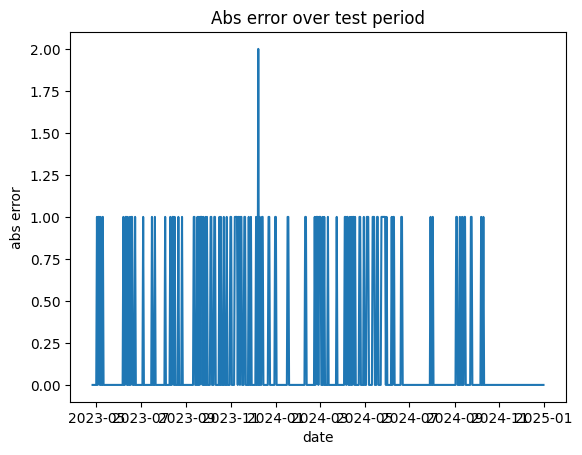

In [17]:
# %% Cell 8: Naive baseline, 1-step persistence
naive_vals = target.to_series().shift(1).loc[y_test.time_index]
naive_pred = TimeSeries.from_times_and_values(y_test.time_index, naive_vals.values)

rmse_naive = rmse(y_test, naive_pred)
mae_naive = mae(y_test, naive_pred)
mape_naive = mape(y_test, naive_pred)

print(f"Model : RMSE={rmse_fin:.3f} | MAE={mae_fin:.3f} | MAPE={mape_fin:.3f}")
print(f"Naive : RMSE={rmse_naive:.3f} | MAE={mae_naive:.3f} | MAPE={mape_naive:.3f}")




# # %% Cell 9: Error by step-into-horizon
err = np.abs(y_test.values().flatten() - test_pred.values().flatten())
plt.plot(y_test.time_index, err)
plt.xlabel("date")
plt.ylabel("abs error")
plt.title("Abs error over test period")
plt.show()

# Saving the model


In [ ]:
# %% Cell 10: Export deployable model
deploy_model = XGBModel(**best_params, **fixed_param)
deploy_model.fit(target, past_covariates=covariates)
deploy_model.save(f"xgb_aqi_rmse{rmse_fin:.3f}_mae{mae_fin:.3f}_mape{mape_fin:.3f}.pkl")
print("Model saved. 1-step-ahead only; re-run daily with latest actuals.")

Model saved. 1-step-ahead only; re-run daily with latest actuals.
